# World Happiness — Feature Selection & Modeling Pipeline
### Identifying the Strongest Predictors of `Life Ladder` — Globally & Regionally

**Pipeline Overview:**
- **Phase 1** — Statistical Pre-Screening (Skewness, Univariate OLS, Bonferroni, VIF)
- **Phase 2** — `find_champion_model()` — GridSearchCV over Polynomial + Ridge/OLS
- **Phase 3** — `calculate_importance()` — Permutation Importance (Truth Finder)
- **Phase 4** — Global run → Regional loop → Heatmap comparison

In [74]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [75]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('cleaned-datasets/HZ_WH_data.csv')

# ── Constants ─────────────────────────────────────────────────────────────────
TARGET       = 'Life Ladder'
ID_COLS      = ['Country Name', 'ISO3', 'Regional Indicator', 'Year']
SKEW_THRESH  = 1.0   # |skew| threshold for log-transform
VIF_THRESH   = 10.0  # maximum allowed VIF
ALPHA        = 0.05  # family-wise error rate before Bonferroni

# All numeric columns that are candidate features (exclude target + identifiers)
ALL_FEATURES = [c for c in df.select_dtypes(include=np.number).columns
                if c not in [TARGET] + ID_COLS]

print(f"Dataset shape : {df.shape}")
print(f"Candidate features ({len(ALL_FEATURES)}): {ALL_FEATURES}")

Dataset shape : (1897, 35)
Candidate features (30): ['Social Support', 'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices', 'Generosity', 'Perceptions Of Corruption', 'Positive Affect', 'Negative Affect', 'Confidence In National Government', 'Electricity Access pct', 'Inflation Rate', 'Internet Penetration', 'Trade Openness', 'GDP Growth Rate', 'GDP/Capita', 'Expected Years Of Schooling', 'Child Mortality Rate', 'Health Expenditure pct of GDP', 'Out Of Pocket Health pct', 'Female Labor Participation', 'Unemployment Rate', 'Life Expectancy', 'Population Growth Rate', 'Population', 'Urbanization Rate', 'Control Of Corruption', 'Govt Effectiveness', 'Political Stability', 'Rule Of Law', 'Regulatory Quality', 'Voice Accountability']


---
## Phase 1 — Statistical Pre-Screening
### 1a · Skewness Test & Log₁₊ Transformation

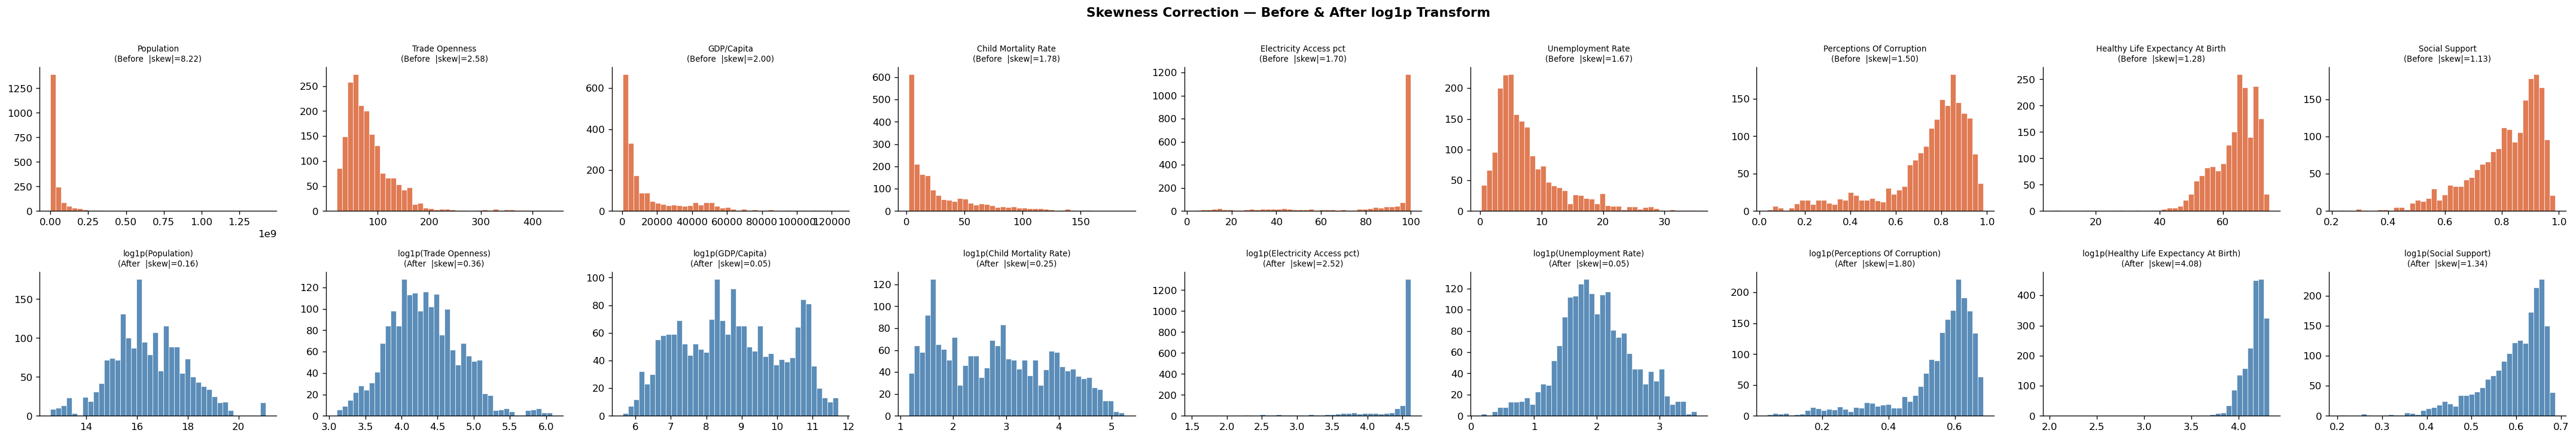


Transformed features (9): ['Population', 'Trade Openness', 'GDP/Capita', 'Child Mortality Rate', 'Electricity Access pct', 'Unemployment Rate', 'Perceptions Of Corruption', 'Healthy Life Expectancy At Birth', 'Social Support']


,Skew (original),Skew (after),Transformed
Inflation Rate,13.765706,13.765706,False
Population,8.224908,0.155036,True
Trade Openness,2.576079,0.363126,True
GDP/Capita,1.997973,0.053108,True
Child Mortality Rate,1.775337,0.252503,True
Electricity Access pct,-1.699739,-2.515741,True
Unemployment Rate,1.674911,0.054770,True
Perceptions Of Corruption,-1.501025,-1.799539,True
Healthy Life Expectancy At Birth,-1.275408,-4.079846,True
GDP Growth Rate,-1.184321,-1.184321,False


In [76]:
def screen_and_transform_skew(data: pd.DataFrame,
                               features: list,
                               skew_thresh: float = SKEW_THRESH) -> tuple[pd.DataFrame, list]:
    """
    Compute skewness for each feature. Apply np.log1p to features with
    |skew| > skew_thresh AND all values >= 0 (safe for log1p).

    Returns
    -------
    data_t      : DataFrame with transformed columns (in-place copy)
    transformed : list of column names that were transformed
    """
    data_t      = data.copy()
    skewness    = data_t[features].skew().sort_values(key=abs, ascending=False)
    transformed = []

    for feat, skew_val in skewness.items():
        if abs(skew_val) > skew_thresh and data_t[feat].min() >= 0:
            data_t[feat] = np.log1p(data_t[feat])
            transformed.append(feat)

    # ── Before / After histograms ─────────────────────────────────────────────
    if transformed:
        n      = len(transformed)
        fig, axes = plt.subplots(2, n, figsize=(max(4 * n, 8), 6))
        if n == 1:
            axes = axes.reshape(2, 1)

        for col_idx, feat in enumerate(transformed):
            # "Before" values = original (log1p already applied, so reverse)
            original = np.expm1(data_t[feat])   # undo log1p
            transformed_vals = data_t[feat]

            axes[0, col_idx].hist(original, bins=40, color='#e07b54', edgecolor='white', linewidth=0.4)
            axes[0, col_idx].set_title(f'{feat}\n(Before  |skew|={abs(skewness[feat]):.2f})', fontsize=8)

            axes[1, col_idx].hist(transformed_vals, bins=40, color='#5b8db8', edgecolor='white', linewidth=0.4)
            axes[1, col_idx].set_title(f'log1p({feat})\n(After  |skew|={abs(data_t[feat].skew()):.2f})', fontsize=8)

        fig.suptitle('Skewness Correction — Before & After log1p Transform', fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        print("No features exceeded the skewness threshold — no transforms applied.")

    print(f"\nTransformed features ({len(transformed)}): {transformed}")
    return data_t, transformed


# ── Apply to global dataset ───────────────────────────────────────────────────
df_t, transformed_cols = screen_and_transform_skew(df, ALL_FEATURES)

# Show skewness table
skew_table = pd.DataFrame({
    'Skew (original)': df[ALL_FEATURES].skew(),
    'Skew (after)'   : df_t[ALL_FEATURES].skew(),
    'Transformed'    : [f in transformed_cols for f in ALL_FEATURES]
}).sort_values('Skew (original)', key=abs, ascending=False)
skew_table

### 1b–1c · Univariate OLS + Bonferroni Correction

In [77]:
def bonferroni_screen(data: pd.DataFrame,
                       features: list,
                       target: str = TARGET,
                       alpha: float = ALPHA) -> tuple[list, pd.DataFrame]:
    """
    Run a univariate OLS of each feature against `target`.
    Apply Bonferroni correction and return only significant features.

    Returns
    -------
    sig_features : list of features that survive the correction
    ols_table    : DataFrame with R², p-value, and significance flag
    """
    n_tests          = len(features)
    alpha_corrected  = alpha / n_tests
    records          = []

    y = data[target]

    for feat in features:
        # Skip features with zero variance (constant within this subset)
        if data[feat].std() == 0:
            continue

        X_const = sm.add_constant(data[feat])
        model   = sm.OLS(y, X_const).fit()

        # Guard: statsmodels may drop the feature column if it's collinear with
        # the constant (e.g. near-constant in a small regional subset).
        if len(model.pvalues) < 2:
            continue

        p_val   = model.pvalues.iloc[1]   # slope p-value (index 0 is intercept)
        r2      = model.rsquared
        records.append({'Feature': feat, 'R²': round(r2, 4), 'p-value': p_val})

    ols_table = (pd.DataFrame(records)
                   .sort_values('p-value')
                   .reset_index(drop=True))
    ols_table['Significant (Bonferroni)'] = ols_table['p-value'] < alpha_corrected

    sig_features = ols_table.loc[ols_table['Significant (Bonferroni)'], 'Feature'].tolist()

    print(f"Bonferroni α = {alpha:.4f} / {n_tests} = {alpha_corrected:.6f}")
    print(f"Features surviving Bonferroni ({len(sig_features)}): {sig_features}")
    return sig_features, ols_table


sig_features, ols_table = bonferroni_screen(df_t, ALL_FEATURES)
ols_table

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (28): ['GDP/Capita', 'Child Mortality Rate', 'Govt Effectiveness', 'Life Expectancy', 'Social Support', 'Regulatory Quality', 'Control Of Corruption', 'Rule Of Law', 'Internet Penetration', 'Urbanization Rate', 'Voice Accountability', 'Healthy Life Expectancy At Birth', 'Political Stability', 'Freedom To Make Life Choices', 'Electricity Access pct', 'Positive Affect', 'Out Of Pocket Health pct', 'Perceptions Of Corruption', 'Health Expenditure pct of GDP', 'Expected Years Of Schooling', 'Negative Affect', 'Population Growth Rate', 'Trade Openness', 'Generosity', 'Female Labor Participation', 'Inflation Rate', 'Population', 'GDP Growth Rate']


,Feature,R²,p-value,Significant (Bonferroni)
0,GDP/Capita,0.6700,0.000000e+00,True
1,Child Mortality Rate,0.5475,0.000000e+00,True
2,Govt Effectiveness,0.5720,0.000000e+00,True
3,Life Expectancy,0.5638,0.000000e+00,True
4,Social Support,0.5174,4.351918e-302,True
5,Regulatory Quality,0.5168,1.208065e-301,True
6,Control Of Corruption,0.5088,6.964121e-295,True
7,Rule Of Law,0.4904,9.962601e-280,True
8,Internet Penetration,0.4792,9.945001e-271,True
9,Urbanization Rate,0.4605,3.004785e-256,True


### 1d · Variance Inflation Factor (VIF) Pruning

In [78]:
def vif_prune(data: pd.DataFrame,
              features: list,
              vif_thresh: float = VIF_THRESH) -> tuple[list, pd.DataFrame]:
    """
    Iteratively remove the feature with the highest VIF until all VIF <= vif_thresh.

    Returns
    -------
    remaining_features : list of features after pruning
    vif_final          : DataFrame of final VIF scores
    """
    remaining = features.copy()
    iteration = 1

    while True:
        X_matrix = data[remaining].values
        vif_vals  = [variance_inflation_factor(X_matrix, i) for i in range(X_matrix.shape[1])]
        vif_df    = pd.DataFrame({'Feature': remaining, 'VIF': vif_vals}).sort_values('VIF', ascending=False)

        max_vif  = vif_df['VIF'].iloc[0]
        max_feat = vif_df['Feature'].iloc[0]

        if max_vif <= vif_thresh:
            print(f"✓ All VIF ≤ {vif_thresh} after {iteration - 1} pruning step(s).")
            break

        print(f"  Iter {iteration}: Dropping '{max_feat}'  (VIF = {max_vif:.2f})")
        remaining.remove(max_feat)
        iteration += 1

    # Final VIF table
    X_matrix = data[remaining].values
    vif_final = pd.DataFrame({
        'Feature': remaining,
        'VIF'    : [variance_inflation_factor(X_matrix, i) for i in range(len(remaining))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

    print(f"\nFinal feature set ({len(remaining)}): {remaining}")
    return remaining, vif_final


final_features, vif_table = vif_prune(df_t, sig_features)
vif_table

  Iter 1: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 2646.12)
  Iter 2: Dropping 'Life Expectancy'  (VIF = 607.45)
  Iter 3: Dropping 'GDP/Capita'  (VIF = 363.87)
  Iter 4: Dropping 'Electricity Access pct'  (VIF = 220.76)
  Iter 5: Dropping 'Social Support'  (VIF = 186.70)
  Iter 6: Dropping 'Population'  (VIF = 153.33)
  Iter 7: Dropping 'Positive Affect'  (VIF = 82.83)
  Iter 8: Dropping 'Trade Openness'  (VIF = 74.52)
  Iter 9: Dropping 'Child Mortality Rate'  (VIF = 48.12)
  Iter 10: Dropping 'Freedom To Make Life Choices'  (VIF = 41.34)
  Iter 11: Dropping 'Perceptions Of Corruption'  (VIF = 40.01)
  Iter 12: Dropping 'Rule Of Law'  (VIF = 28.43)
  Iter 13: Dropping 'Expected Years Of Schooling'  (VIF = 26.11)
  Iter 14: Dropping 'Urbanization Rate'  (VIF = 17.74)
  Iter 15: Dropping 'Govt Effectiveness'  (VIF = 16.29)
  Iter 16: Dropping 'Negative Affect'  (VIF = 12.40)
✓ All VIF ≤ 10.0 after 16 pruning step(s).

Final feature set (12): ['Regulatory Quality', 'Control O

,Feature,VIF
0,Regulatory Quality,9.626816
1,Female Labor Participation,9.392968
2,Health Expenditure pct of GDP,9.308498
3,Control Of Corruption,8.263151
4,Internet Penetration,7.553897
5,Out Of Pocket Health pct,6.208893
6,Voice Accountability,4.809094
7,Political Stability,3.057574
8,Population Growth Rate,2.396671
9,GDP Growth Rate,1.781001


---
## Phase 2 — `find_champion_model(X, y)`
GridSearchCV over `PolynomialFeatures` degree × {`LinearRegression`, `Ridge`} with 5-fold CV.

In [79]:
def find_champion_model(X: pd.DataFrame, y: pd.Series,
                         cv: int = 5,
                         verbose: bool = True) -> tuple:
    """
    Search for the best pipeline over:
      - PolynomialFeatures degree ∈ {1, 2, 3}
      - LinearRegression  (no regularization)
      - Ridge             with alpha ∈ np.logspace(-3, 3, 7)

    Uses 5-fold CV minimising MSE (neg_mean_squared_error).

    Returns
    -------
    best_pipeline : fitted sklearn Pipeline
    description   : human-readable string of the winning config
    cv_results    : DataFrame of all tried configurations
    """
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(include_bias=False)),
        ('model',  LinearRegression())          # placeholder, overridden by grid
    ])

    # Build param grid as a LIST to allow different estimator types
    # (LinearRegression has no alpha; Ridge does)
    param_grid = []

    # --- LinearRegression branch ---
    for degree in [1, 2, 3]:
        param_grid.append({
            'poly__degree': [degree],
            'model':        [LinearRegression()]
        })

    # --- Ridge branch ---
    for degree in [1, 2, 3]:
        for alpha in np.logspace(-3, 3, 7):
            param_grid.append({
                'poly__degree': [degree],
                'model':        [Ridge(alpha=alpha)]
            })

    grid_search = GridSearchCV(
        estimator  = base_pipeline,
        param_grid = param_grid,
        scoring    = 'neg_mean_squared_error',
        cv         = cv,
        refit      = True,
        n_jobs     = -1,
    )
    grid_search.fit(X, y)

    best_params = grid_search.best_params_
    best_model  = best_params['model']
    best_degree = best_params['poly__degree']
    best_mse    = -grid_search.best_score_

    # Build human-readable description
    model_name = type(best_model).__name__
    if model_name == 'Ridge':
        description = f"Ridge, Degree {best_degree}, Alpha {best_model.alpha:.3f}"
    else:
        description = f"LinearRegression, Degree {best_degree}"

    if verbose:
        print(f"  Champion : {description}")
        print(f"  CV MSE   : {best_mse:.4f}  (RMSE ≈ {best_mse**0.5:.4f})")

    # Compact results table
    results_df = (pd.DataFrame(grid_search.cv_results_)
                    [['param_poly__degree', 'param_model', 'mean_test_score', 'std_test_score']]
                    .assign(CV_MSE = lambda d: -d['mean_test_score'])
                    .sort_values('CV_MSE')
                    .reset_index(drop=True))

    return grid_search.best_estimator_, description, results_df


print("find_champion_model() defined ✓")

find_champion_model() defined ✓


---
## Phase 3 — `calculate_importance(model, X_test, y_test)`
Permutation Importance with 500 shuffles per feature. The full pipeline re-computes polynomial terms on shuffled data, so we capture the **Total Feature Impact** (direct + interaction effects).

In [80]:
def calculate_importance(pipeline,
                          X_test: pd.DataFrame,
                          y_test: pd.Series,
                          n_repeats: int = 500,
                          title: str = 'Permutation Feature Importance',
                          top_n: int = None) -> tuple:
    """
    Compute permutation importance on base features.

    Because we pass `X_test` (base feature space) into the full pipeline,
    shuffling one base column causes the pipeline to recompute ALL polynomial/
    interaction terms that involve it — capturing Total Feature Impact.

    Parameters
    ----------
    pipeline   : fitted sklearn Pipeline (scaler → poly → model)
    X_test     : base feature DataFrame (NOT yet poly-expanded)
    y_test     : target Series
    n_repeats  : number of shuffle repeats (default 500)
    title      : plot title
    top_n      : limit bar chart to top N features (None = all)

    Returns
    -------
    importance_df : sorted DataFrame ['Feature', 'Importance Mean', 'Importance Std']
    fig           : matplotlib Figure
    """
    result = permutation_importance(
        pipeline, X_test, y_test,
        n_repeats   = n_repeats,
        scoring     = 'neg_mean_squared_error',
        random_state = RANDOM_STATE,
        n_jobs      = -1,
    )

    importance_df = (pd.DataFrame({
        'Feature'         : X_test.columns.tolist(),
        'Importance Mean' : result.importances_mean,   # positive = more MSE when shuffled
        'Importance Std'  : result.importances_std,
    })
    .sort_values('Importance Mean', ascending=False)
    .reset_index(drop=True))

    # ── Horizontal bar chart ───────────────────────────────────────────────────
    plot_df = importance_df.head(top_n) if top_n else importance_df
    # Reverse for bottom-to-top plotting
    plot_df = plot_df.iloc[::-1]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))

    colors = ['#c0392b' if v > 0 else '#7f8c8d' for v in plot_df['Importance Mean']]
    ax.barh(plot_df['Feature'], plot_df['Importance Mean'],
            xerr=plot_df['Importance Std'],
            color=colors, edgecolor='white', linewidth=0.5,
            error_kw=dict(elinewidth=0.8, capsize=3, ecolor='#555555'))

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean Increase in MSE (when feature is shuffled)')
    ax.set_title(title, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

    return importance_df, fig


print("calculate_importance() defined ✓")

calculate_importance() defined ✓


---
## Phase 4 — Execution & Comparison
### 4a · Global Run


  Global  —  1897 rows  |  12 features
  Champion : Ridge, Degree 2, Alpha 100.000
  CV MSE   : 0.3620  (RMSE ≈ 0.6017)
  Test MSE : 0.3295  (RMSE ≈ 0.5740)


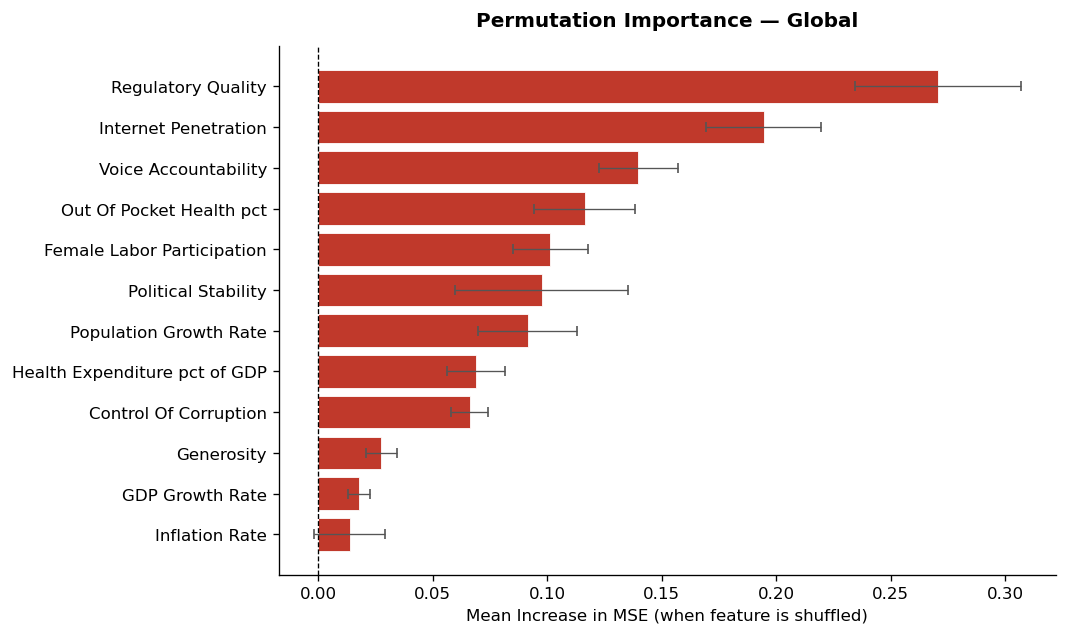

In [81]:
def run_pipeline(data: pd.DataFrame,
                  features: list,
                  target: str = TARGET,
                  label: str = 'Global',
                  n_repeats_perm: int = 500) -> dict:
    """
    Full pipeline for a given dataset slice:
      Phase 1 → Phase 2 → Phase 3

    Parameters
    ----------
    data           : DataFrame (already log-transformed where needed)
    features       : pre-screened feature list (output of Phase 1 on the slice)
    target         : target column name
    label          : display label for print / plot titles
    n_repeats_perm : permutation repeats for Phase 3

    Returns
    -------
    dict with keys: label, champion_desc, importance_df, test_mse, features_used
    """
    X = data[features]
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    print(f"\n{'='*60}")
    print(f"  {label}  —  {len(data)} rows  |  {len(features)} features")
    print(f"{'='*60}")

    # Phase 2
    champion, desc, _ = find_champion_model(X_train, y_train, verbose=True)

    # Hold-out MSE
    y_pred   = champion.predict(X_test)
    test_mse = mean_squared_error(y_test, y_pred)
    print(f"  Test MSE : {test_mse:.4f}  (RMSE ≈ {test_mse**0.5:.4f})")

    # Phase 3
    imp_df, _ = calculate_importance(
        champion, X_test, y_test,
        n_repeats = n_repeats_perm,
        title     = f'Permutation Importance — {label}'
    )

    return {
        'label'        : label,
        'champion_desc': desc,
        'importance_df': imp_df,
        'test_mse'     : test_mse,
        'features_used': features,
    }


# ── Run Global ────────────────────────────────────────────────────────────────
global_result = run_pipeline(df_t, final_features, label='Global')

### 4b · Regional Loop
Each region gets its own Phase 1 pre-screening (skewness + Bonferroni + VIF) before champion search, so the feature set is tailored to regional data characteristics.

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (22): ['GDP/Capita', 'Child Mortality Rate', 'Positive Affect', 'Freedom To Make Life Choices', 'Internet Penetration', 'Unemployment Rate', 'Rule Of Law', 'Social Support', 'Out Of Pocket Health pct', 'Govt Effectiveness', 'Healthy Life Expectancy At Birth', 'Political Stability', 'Control Of Corruption', 'Voice Accountability', 'Electricity Access pct', 'Population Growth Rate', 'Regulatory Quality', 'Female Labor Participation', 'Negative Affect', 'Trade Openness', 'Life Expectancy', 'Perceptions Of Corruption']
  Iter 1: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 230900.72)
  Iter 2: Dropping 'Electricity Access pct'  (VIF = 13352.05)
  Iter 3: Dropping 'GDP/Capita'  (VIF = 3386.07)
  Iter 4: Dropping 'Life Expectancy'  (VIF = 1051.93)
  Iter 5: Dropping 'Trade Openness'  (VIF = 792.18)
  Iter 6: Dropping 'Female Labor Participation'  (VIF = 607.12)
  Iter 7: Dropping 'Perceptions Of Corruption'  (VIF = 36

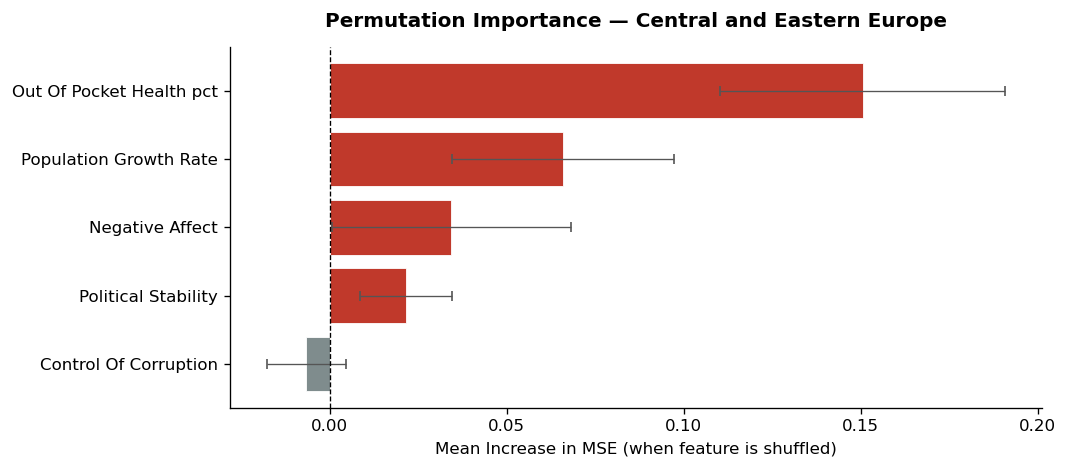

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (17): ['Positive Affect', 'Social Support', 'Unemployment Rate', 'Freedom To Make Life Choices', 'Out Of Pocket Health pct', 'Internet Penetration', 'Regulatory Quality', 'Voice Accountability', 'Political Stability', 'Negative Affect', 'Health Expenditure pct of GDP', 'Generosity', 'Population', 'Trade Openness', 'GDP/Capita', 'Confidence In National Government', 'Rule Of Law']
  Iter 1: Dropping 'Population'  (VIF = 921.63)
  Iter 2: Dropping 'Social Support'  (VIF = 499.04)
  Iter 3: Dropping 'GDP/Capita'  (VIF = 243.76)
  Iter 4: Dropping 'Freedom To Make Life Choices'  (VIF = 108.24)
  Iter 5: Dropping 'Trade Openness'  (VIF = 84.88)
  Iter 6: Dropping 'Positive Affect'  (VIF = 60.37)
  Iter 7: Dropping 'Out Of Pocket Health pct'  (VIF = 33.67)
  Iter 8: Dropping 'Unemployment Rate'  (VIF = 23.70)
  Iter 9: Dropping 'Voice Accountability'  (VIF = 18.89)
  Iter 10: Dropping 'Rule Of Law'  (VIF = 16.07)
  Iter 11: D

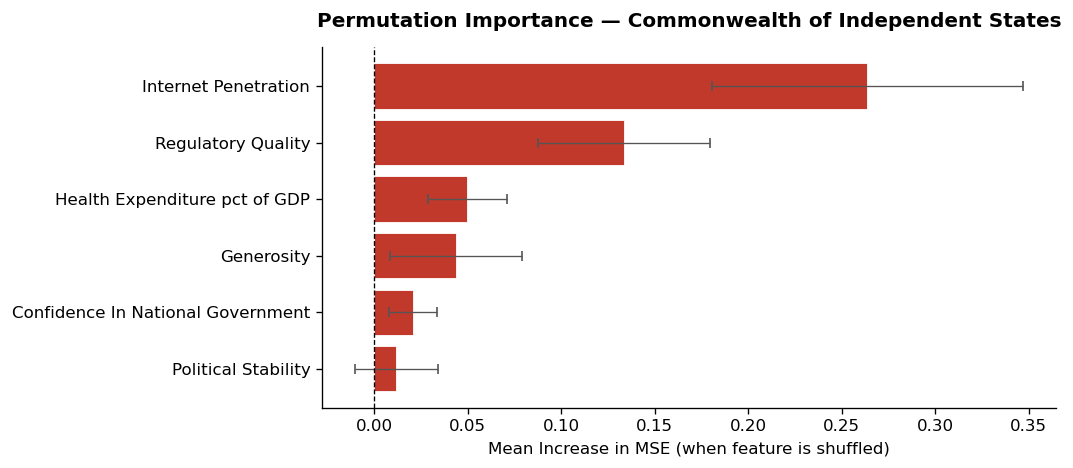

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (23): ['Internet Penetration', 'Electricity Access pct', 'Child Mortality Rate', 'GDP/Capita', 'Life Expectancy', 'Healthy Life Expectancy At Birth', 'Regulatory Quality', 'Voice Accountability', 'Population', 'Rule Of Law', 'Govt Effectiveness', 'Expected Years Of Schooling', 'Urbanization Rate', 'Population Growth Rate', 'Control Of Corruption', 'Inflation Rate', 'Perceptions Of Corruption', 'Positive Affect', 'Health Expenditure pct of GDP', 'GDP Growth Rate', 'Generosity', 'Trade Openness', 'Unemployment Rate']
  Iter 1: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 1055803.34)
  Iter 2: Dropping 'Population'  (VIF = 114293.02)
  Iter 3: Dropping 'Life Expectancy'  (VIF = 35206.64)
  Iter 4: Dropping 'Electricity Access pct'  (VIF = 34744.20)
  Iter 5: Dropping 'Urbanization Rate'  (VIF = 10025.41)
  Iter 6: Dropping 'Expected Years Of Schooling'  (VIF = 7349.34)
  Iter 7: Dropping 'GDP/Capita'  (VIF = 1914.7

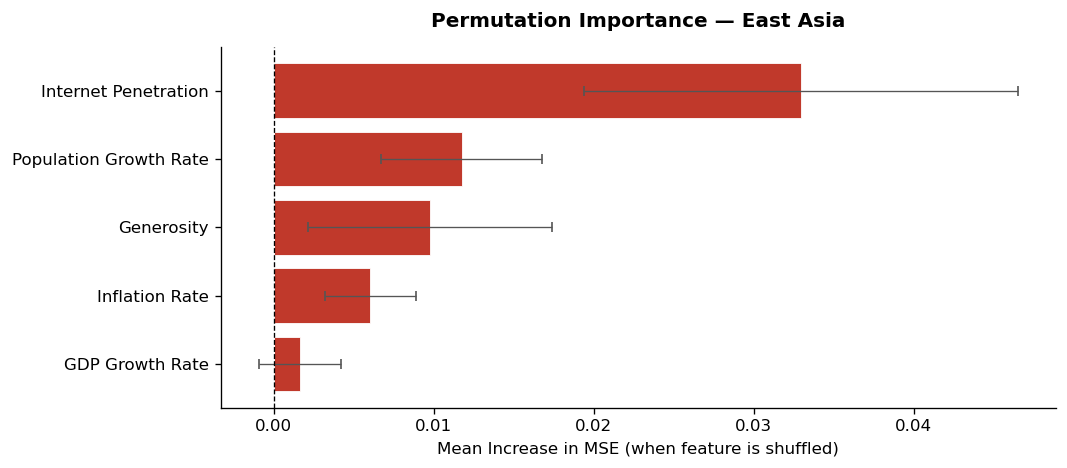

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (24): ['GDP/Capita', 'Child Mortality Rate', 'Govt Effectiveness', 'Life Expectancy', 'Electricity Access pct', 'Social Support', 'Positive Affect', 'Freedom To Make Life Choices', 'Voice Accountability', 'Rule Of Law', 'Control Of Corruption', 'Healthy Life Expectancy At Birth', 'Regulatory Quality', 'Negative Affect', 'Urbanization Rate', 'Generosity', 'Health Expenditure pct of GDP', 'Internet Penetration', 'Political Stability', 'Expected Years Of Schooling', 'Out Of Pocket Health pct', 'Confidence In National Government', 'Female Labor Participation', 'Inflation Rate']
  Iter 1: Dropping 'Electricity Access pct'  (VIF = 5318.87)
  Iter 2: Dropping 'Life Expectancy'  (VIF = 1817.99)
  Iter 3: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 1067.51)
  Iter 4: Dropping 'GDP/Capita'  (VIF = 857.85)
  Iter 5: Dropping 'Social Support'  (VIF = 803.03)
  Iter 6: Dropping 'Positive Affect'  (VIF = 250.85)
  Iter 7: Dr

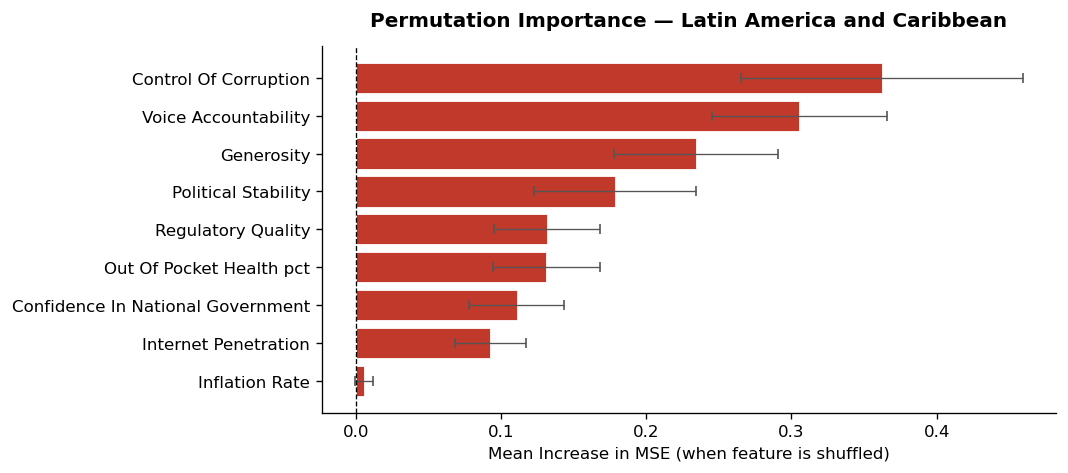

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (27): ['Positive Affect', 'Unemployment Rate', 'GDP/Capita', 'Political Stability', 'Govt Effectiveness', 'Female Labor Participation', 'Control Of Corruption', 'Out Of Pocket Health pct', 'Rule Of Law', 'Perceptions Of Corruption', 'Freedom To Make Life Choices', 'Confidence In National Government', 'Regulatory Quality', 'Urbanization Rate', 'Social Support', 'Child Mortality Rate', 'Life Expectancy', 'Inflation Rate', 'Healthy Life Expectancy At Birth', 'Population', 'Trade Openness', 'GDP Growth Rate', 'Negative Affect', 'Population Growth Rate', 'Electricity Access pct', 'Generosity', 'Health Expenditure pct of GDP']
  Iter 1: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 33334.92)
  Iter 2: Dropping 'Electricity Access pct'  (VIF = 8040.83)
  Iter 3: Dropping 'Life Expectancy'  (VIF = 5855.78)
  Iter 4: Dropping 'GDP/Capita'  (VIF = 1450.66)
  Iter 5: Dropping 'Population'  (VIF = 727.45)
  Iter 6: Dropping 

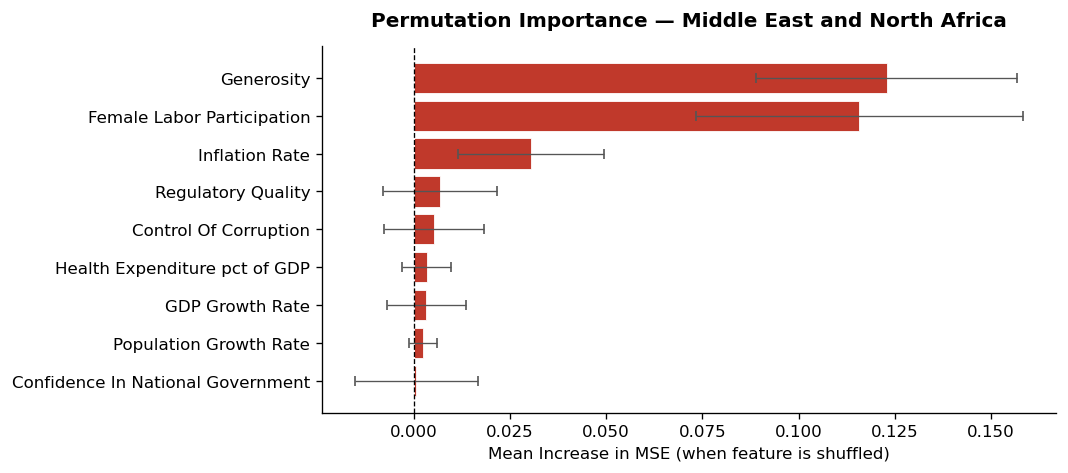

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (20): ['Freedom To Make Life Choices', 'Govt Effectiveness', 'Rule Of Law', 'Social Support', 'Health Expenditure pct of GDP', 'Control Of Corruption', 'Positive Affect', 'Generosity', 'Trade Openness', 'Political Stability', 'Voice Accountability', 'Expected Years Of Schooling', 'Perceptions Of Corruption', 'GDP/Capita', 'Healthy Life Expectancy At Birth', 'Out Of Pocket Health pct', 'Population', 'Negative Affect', 'Confidence In National Government', 'Female Labor Participation']
  Iter 1: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 109756.29)
  Iter 2: Dropping 'Population'  (VIF = 12529.33)
  Iter 3: Dropping 'Social Support'  (VIF = 10370.02)
  Iter 4: Dropping 'GDP/Capita'  (VIF = 6349.28)
  Iter 5: Dropping 'Female Labor Participation'  (VIF = 2962.28)
  Iter 6: Dropping 'Positive Affect'  (VIF = 1855.94)
  Iter 7: Dropping 'Rule Of Law'  (VIF = 1569.30)
  Iter 8: Dropping 'Freedom To Make Life Choices'

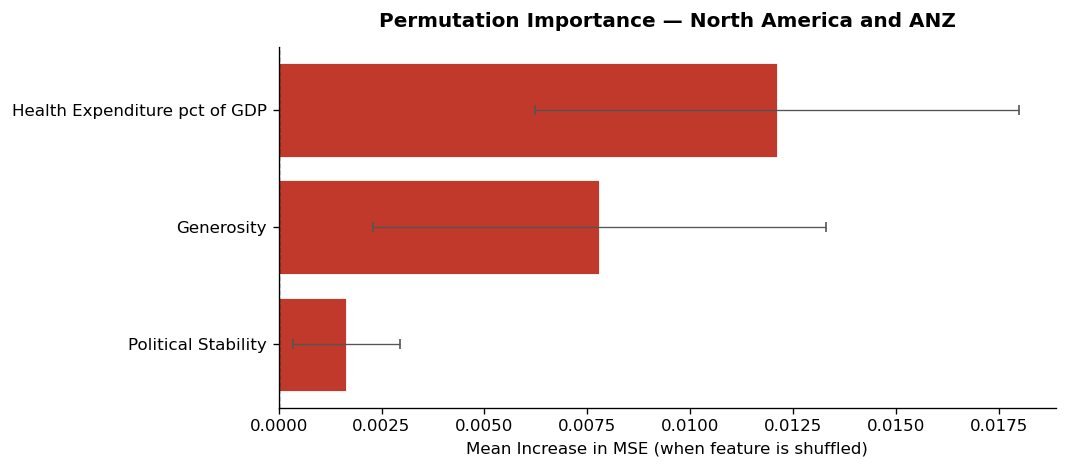

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (7): ['Health Expenditure pct of GDP', 'Trade Openness', 'Unemployment Rate', 'Negative Affect', 'Social Support', 'Urbanization Rate', 'Rule Of Law']
  Iter 1: Dropping 'Trade Openness'  (VIF = 106.44)
  Iter 2: Dropping 'Unemployment Rate'  (VIF = 31.26)
  Iter 3: Dropping 'Negative Affect'  (VIF = 11.76)
✓ All VIF ≤ 10.0 after 3 pruning step(s).

Final feature set (4): ['Health Expenditure pct of GDP', 'Social Support', 'Urbanization Rate', 'Rule Of Law']

  South Asia  —  96 rows  |  4 features
  Champion : Ridge, Degree 1, Alpha 1.000
  CV MSE   : 0.2412  (RMSE ≈ 0.4911)
  Test MSE : 0.4391  (RMSE ≈ 0.6627)


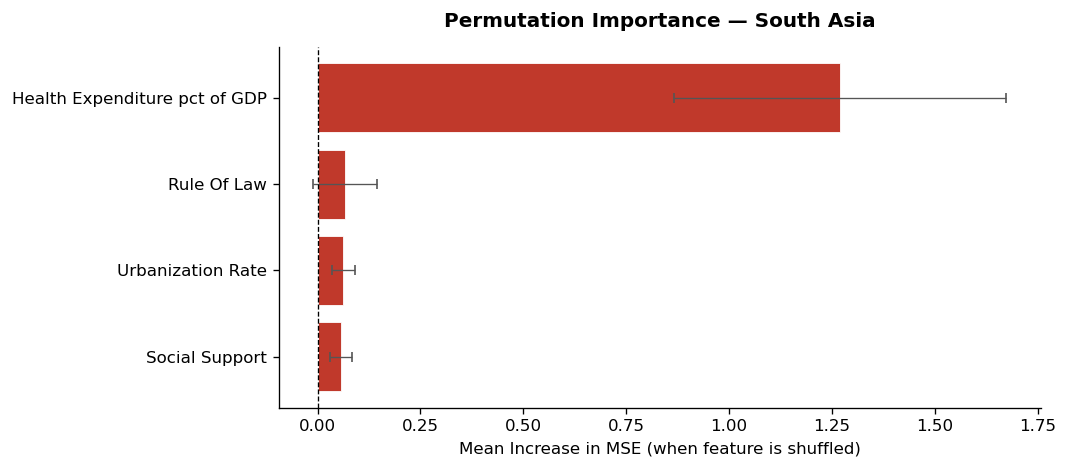

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (20): ['Healthy Life Expectancy At Birth', 'Child Mortality Rate', 'Life Expectancy', 'GDP/Capita', 'Rule Of Law', 'Regulatory Quality', 'Govt Effectiveness', 'Control Of Corruption', 'Trade Openness', 'Urbanization Rate', 'Social Support', 'Internet Penetration', 'Negative Affect', 'Perceptions Of Corruption', 'Out Of Pocket Health pct', 'Electricity Access pct', 'Political Stability', 'Population', 'Expected Years Of Schooling', 'Inflation Rate']
  Iter 1: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 56378.09)
  Iter 2: Dropping 'Electricity Access pct'  (VIF = 15162.67)
  Iter 3: Dropping 'Life Expectancy'  (VIF = 7224.79)
  Iter 4: Dropping 'Population'  (VIF = 1839.12)
  Iter 5: Dropping 'GDP/Capita'  (VIF = 1570.22)
  Iter 6: Dropping 'Social Support'  (VIF = 622.40)
  Iter 7: Dropping 'Child Mortality Rate'  (VIF = 249.71)
  Iter 8: Dropping 'Urbanization Rate'  (VIF = 124.49)
  Iter 9: Dropping 'Control 

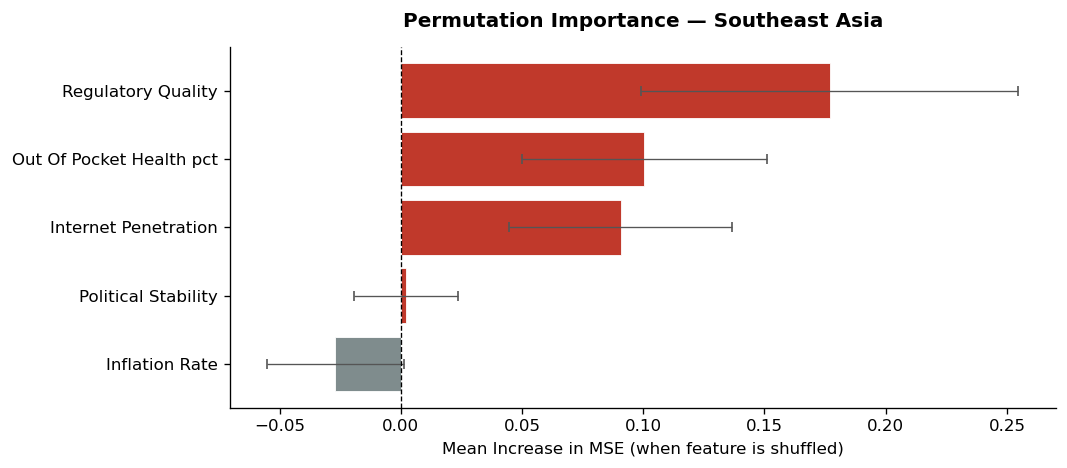

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (23): ['GDP/Capita', 'Internet Penetration', 'Govt Effectiveness', 'Electricity Access pct', 'Regulatory Quality', 'Social Support', 'Urbanization Rate', 'Child Mortality Rate', 'Positive Affect', 'Trade Openness', 'Rule Of Law', 'Voice Accountability', 'Life Expectancy', 'Expected Years Of Schooling', 'Unemployment Rate', 'Population Growth Rate', 'Control Of Corruption', 'Female Labor Participation', 'Freedom To Make Life Choices', 'Healthy Life Expectancy At Birth', 'Inflation Rate', 'Perceptions Of Corruption', 'Political Stability']
  Iter 1: Dropping 'Healthy Life Expectancy At Birth'  (VIF = 7764.98)
  Iter 2: Dropping 'GDP/Capita'  (VIF = 391.44)
  Iter 3: Dropping 'Life Expectancy'  (VIF = 279.23)
  Iter 4: Dropping 'Child Mortality Rate'  (VIF = 235.00)
  Iter 5: Dropping 'Trade Openness'  (VIF = 174.71)
  Iter 6: Dropping 'Positive Affect'  (VIF = 139.75)
  Iter 7: Dropping 'Perceptions Of Corruption'  (VIF 

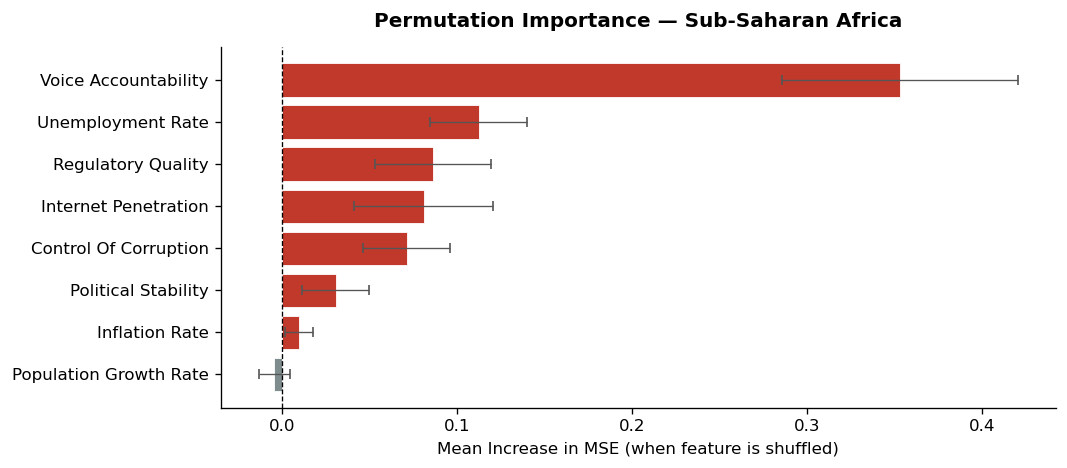

Bonferroni α = 0.0500 / 30 = 0.001667
Features surviving Bonferroni (21): ['Regulatory Quality', 'Govt Effectiveness', 'Control Of Corruption', 'Rule Of Law', 'Perceptions Of Corruption', 'Negative Affect', 'GDP/Capita', 'Freedom To Make Life Choices', 'Social Support', 'Positive Affect', 'Voice Accountability', 'Unemployment Rate', 'Out Of Pocket Health pct', 'Confidence In National Government', 'Female Labor Participation', 'Internet Penetration', 'Generosity', 'Urbanization Rate', 'Population Growth Rate', 'Political Stability', 'Child Mortality Rate']
  Iter 1: Dropping 'Social Support'  (VIF = 1631.52)
  Iter 2: Dropping 'GDP/Capita'  (VIF = 1017.22)
  Iter 3: Dropping 'Positive Affect'  (VIF = 446.19)
  Iter 4: Dropping 'Voice Accountability'  (VIF = 257.17)
  Iter 5: Dropping 'Freedom To Make Life Choices'  (VIF = 226.02)
  Iter 6: Dropping 'Female Labor Participation'  (VIF = 176.30)
  Iter 7: Dropping 'Rule Of Law'  (VIF = 150.81)
  Iter 8: Dropping 'Urbanization Rate'  (VIF =

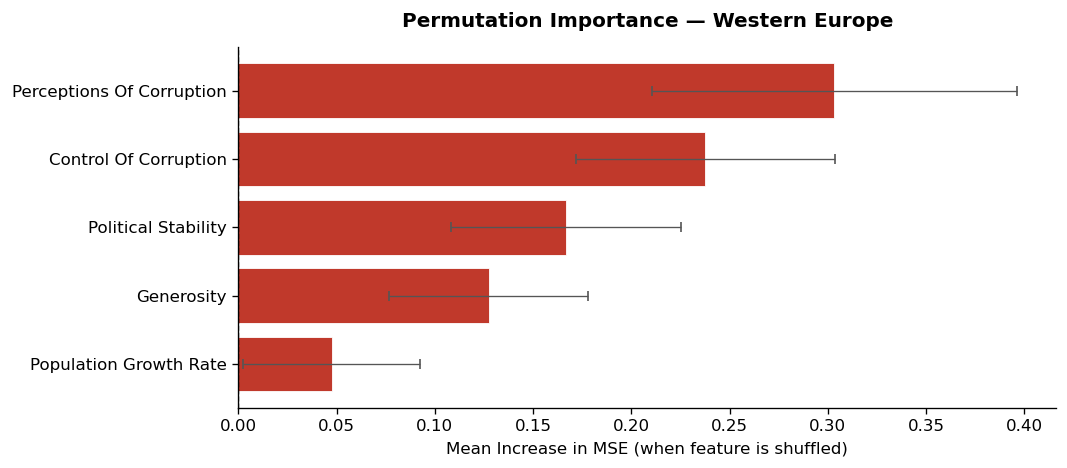


Done — 10 regions processed.


In [82]:
MIN_REGION_SAMPLES = 30   # guard: skip regions too small for CV

regional_results = {}

for region in sorted(df_t['Regional Indicator'].unique()):
    subset = df_t[df_t['Regional Indicator'] == region].copy()

    if len(subset) < MIN_REGION_SAMPLES:
        print(f"  SKIP '{region}' — only {len(subset)} samples (< {MIN_REGION_SAMPLES})")
        continue

    # ── Phase 1 for this region ───────────────────────────────────────────────
    # Skewness already handled on global df_t; just re-run Bonferroni + VIF
    reg_sig, _  = bonferroni_screen(subset, ALL_FEATURES)

    if len(reg_sig) < 2:
        print(f"  SKIP '{region}' — fewer than 2 significant features after Bonferroni")
        continue

    reg_final, _ = vif_prune(subset, reg_sig)

    if len(reg_final) < 1:
        print(f"  SKIP '{region}' — no features survived VIF pruning")
        continue

    # ── Phases 2 & 3 ─────────────────────────────────────────────────────────
    result = run_pipeline(subset, reg_final, label=region)
    regional_results[region] = result

print(f"\nDone — {len(regional_results)} regions processed.")

### 4c · Champion Model Summary Table

In [83]:
# Collect all results (Global first, then regions alphabetically)
all_results = [global_result] + [regional_results[r] for r in sorted(regional_results)]

summary_rows = []
for res in all_results:
    top3 = res['importance_df'].head(3)['Feature'].tolist()
    summary_rows.append({
        'Scope'            : res['label'],
        'Champion Model'   : res['champion_desc'],
        'Test RMSE'        : round(res['test_mse'] ** 0.5, 4),
        'Features Used'    : len(res['features_used']),
        'Top-3 Predictors' : ' > '.join(top3),
    })

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_colwidth', 80)
summary_df

,Scope,Champion Model,Test RMSE,Features Used,Top-3 Predictors
0,Global,"Ridge, Degree 2, Alpha 100.000",0.5740,12,Regulatory Quality > Internet Penetration > Voice Accountability
1,Central and Eastern Europe,"Ridge, Degree 1, Alpha 10.000",0.5621,5,Out Of Pocket Health pct > Population Growth Rate > Negative Affect
2,Commonwealth of Independent States,"Ridge, Degree 3, Alpha 100.000",0.3486,6,Internet Penetration > Regulatory Quality > Health Expenditure pct of GDP
3,East Asia,"Ridge, Degree 2, Alpha 10.000",0.3430,5,Internet Penetration > Population Growth Rate > Generosity
4,Latin America and Caribbean,"Ridge, Degree 2, Alpha 10.000",0.4162,9,Control Of Corruption > Voice Accountability > Generosity
5,Middle East and North Africa,"Ridge, Degree 1, Alpha 10.000",0.3941,9,Generosity > Female Labor Participation > Inflation Rate
6,North America and ANZ,"Ridge, Degree 1, Alpha 10.000",0.1266,3,Health Expenditure pct of GDP > Generosity > Political Stability
7,South Asia,"Ridge, Degree 1, Alpha 1.000",0.6627,4,Health Expenditure pct of GDP > Rule Of Law > Urbanization Rate
8,Southeast Asia,"Ridge, Degree 3, Alpha 10.000",0.3987,5,Regulatory Quality > Out Of Pocket Health pct > Internet Penetration
9,Sub-Saharan Africa,"Ridge, Degree 2, Alpha 10.000",0.4882,8,Voice Accountability > Unemployment Rate > Regulatory Quality


### 4d · Feature Importance Heatmap — Global vs Regional
Rows = Global + each region. Columns = union of all features that appeared in at least one run. Values = permutation importance mean (0 = not selected or no measurable impact).

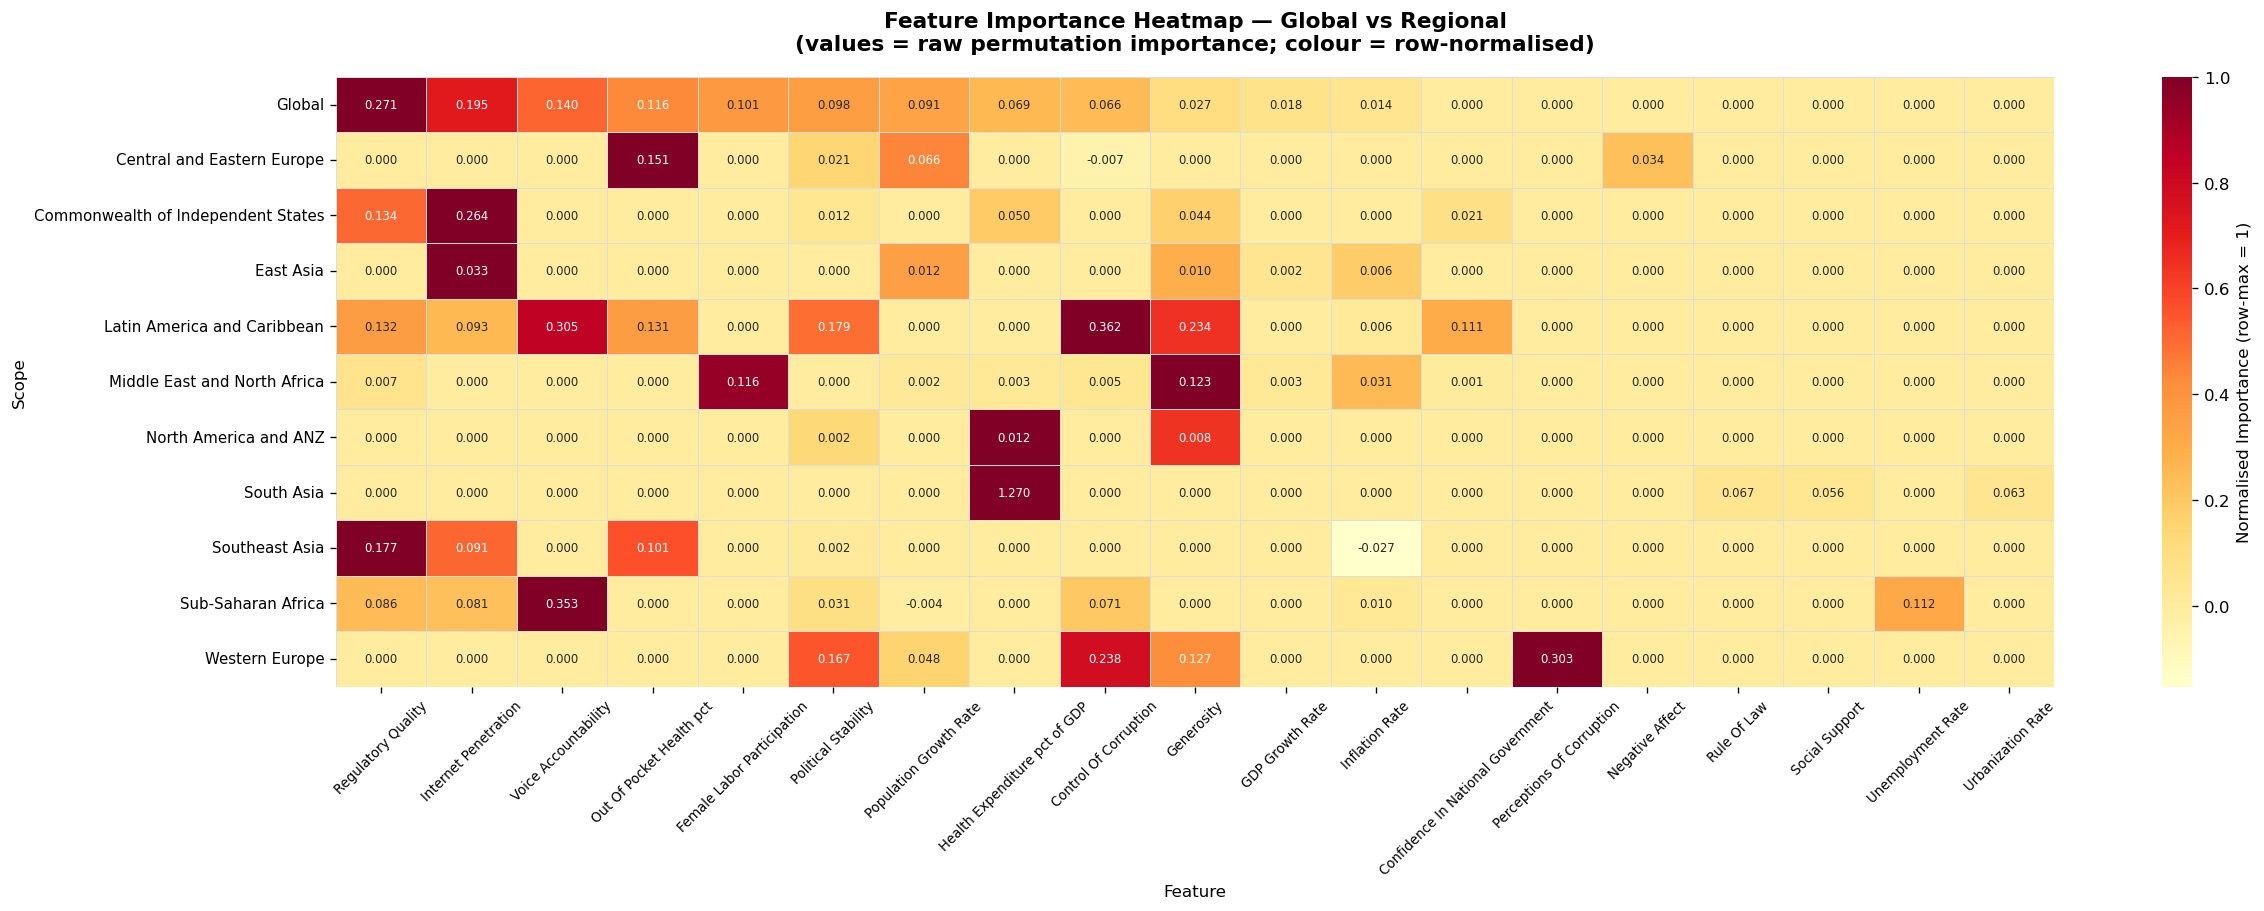


Heatmap complete. Strongest global predictors (left → right):
  1. Regulatory Quality  (importance = 0.2705)
  2. Internet Penetration  (importance = 0.1946)
  3. Voice Accountability  (importance = 0.1398)
  4. Out Of Pocket Health pct  (importance = 0.1163)
  5. Female Labor Participation  (importance = 0.1014)


In [84]:
# ── Build pivot table ─────────────────────────────────────────────────────────
# Collect every feature name that appears in any importance_df
all_feat_names = sorted({
    feat
    for res in all_results
    for feat in res['importance_df']['Feature']
})

# Build rows: scope → {feature: importance_mean}
heatmap_data = {}
for res in all_results:
    row = dict(zip(res['importance_df']['Feature'],
                   res['importance_df']['Importance Mean']))
    # Fill missing features with 0
    heatmap_data[res['label']] = {f: row.get(f, 0.0) for f in all_feat_names}

heatmap_df = pd.DataFrame(heatmap_data, index=all_feat_names).T
# Normalise each row to [0,1] so Global and tiny regions are comparable
heatmap_norm = heatmap_df.div(heatmap_df.max(axis=1).replace(0, 1), axis=0)

# Order columns by global importance (descending)
global_order = (
    heatmap_df.loc['Global']
    .sort_values(ascending=False)
    .index.tolist()
)
heatmap_df   = heatmap_df[global_order]
heatmap_norm = heatmap_norm[global_order]

# ── Plot ──────────────────────────────────────────────────────────────────────
n_rows = len(heatmap_df)
n_cols = len(heatmap_df.columns)
fig, ax = plt.subplots(figsize=(max(14, n_cols * 1.1), max(5, n_rows * 0.7)))

sns.heatmap(
    heatmap_norm,
    annot  = heatmap_df.round(3),    # annotate with raw importance values
    fmt    = '.3f',
    cmap   = 'YlOrRd',
    linewidths = 0.5,
    linecolor  = '#dddddd',
    ax     = ax,
    cbar_kws = {'label': 'Normalised Importance (row-max = 1)'},
    annot_kws = {'size': 7},
)

ax.set_title(
    'Feature Importance Heatmap — Global vs Regional\n'
    '(values = raw permutation importance; colour = row-normalised)',
    fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Feature', fontsize=10)
ax.set_ylabel('Scope', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

print("\nHeatmap complete. Strongest global predictors (left → right):")
for i, feat in enumerate(global_order[:5], 1):
    print(f"  {i}. {feat}  (importance = {heatmap_df.loc['Global', feat]:.4f})")